# Rag

## Setup RAG 

In [ ]:
from langchain_chroma import Chroma
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

# Initialize the embedding model that should match the one used for the existing db
embedding_function = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

# Load the existing db from the local folder
vector_store  = Chroma(
    persist_directory="./chroma_db",
    collection_name="my_rag_db",
    embedding_function=embedding_function,
)

# convert the vector store to a seatch retriever
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

/home/niuniu/Documents/tmp/test/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4755.08it/s]


## Define Tools

In [2]:
# RAG tool

from langchain_core.tools import tool

@tool
def rag_tool(query: str) -> str:
    """Search relevant information in the vector stores as knaowledge base"""
    response = retriever.invoke(query)
    return """

    """.join(d.page_content for d in response)

In [3]:
# tavily tool

from langchain_tavily import TavilySearch

tavily = TavilySearch(max_results=4, topic="general")

# test
response = tavily.invoke("effective intensity")
print(response)

{'query': 'effective intensity', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.tarmacview.com/glossary/effective-intensity', 'title': 'Effective Intensity | Airport Lights Inspection', 'content': '# Effective Intensity. Effective intensity is a photometric parameter that measures the perceived brightness of flashing or pulsed light sources, equating their visibility to an equivalent continuous light source, and is fundamental to safety, regulatory standards, and visual signaling. photometry visual signaling safety standards luminous intensity compliance. # Effective Intensity – Luminous Intensity of Flashing Light Averaged Over Time. **Effective intensity** (Ieff) is a key photometric quantity that enables engineers, regulators, and manufacturers to evaluate and compare the apparent brightness of flashing or pulsed light sources as perceived by the human eye. Unlike simple time-averaged intensity, effective intensity carefully accounts for 

In [4]:
from langchain_core.tools import tool

@tool
def web_search(query: str) -> str:
    """Up-to-date web information via Tavily"""
    return """
    
    """.join(res["content"] for res in tavily.invoke({"query": query})["results"])

## State

In [5]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    route: str          # 'rag' | 'answer' | 'web' | 'end'
    rag: str | None     # rag results
    web: str | None     # web results

## Models

In [6]:
from langchain_groq import ChatGroq
from decouple import Config, RepositoryEnv
env_config = Config(RepositoryEnv("./.env"))

# LLM to decide whether RAG is sufficient
from pydantic import BaseModel

class rag_good(BaseModel):
    is_good: bool

rag_good_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.0,
    api_key=env_config("GROQ_API_KEY"),
).with_structured_output(rag_good)

# LLM to decide wich route to take
from typing import Literal
class which_route(BaseModel):
    route: Literal['rag', 'answer', 'end']
    reply: str | None = None

router_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.0,
    api_key=env_config("GROQ_API_KEY"),
).with_structured_output(which_route)

# LLM for direct answer
answer_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=1.0,
    api_key=env_config("GROQ_API_KEY")
)

## Nodes

In [ ]:
# route node
from langchain_core.messages import AIMessage, HumanMessage

def router_node(state: State) -> State:
    """To decide which node to take for the next step."""
    q = state["messages"][-1].content
    system_instruction = (

         "You are a router that decides how to handle user's question:\n"
         "- use 'end' for pure greeting/small-talks (also provide a 'replay' )\n"
         "- use 'rag' when you don't have sufficient information to give direct answer and knowledge base lookup is needed\n"
         "- use 'answer' when can answer directly or with the chat history without external inforamtion"
    )
    llm_inputs = [system_instruction] + state.get("messages", [])

    decision = router_llm.invoke(llm_inputs)

    if decision.route == "end":
        return {
            "messages": [AIMessage(content=decision.reply or "Bye!")],
            "route": "end",
            "rag": None,
            "web": None
        }
    else:
        return {"route": decision.route}


# rag node
def rag_node(state: State) -> State:
    print("DEBUG", "RAG called")
    query = next((
        m.content 
        for m in reversed(state["messages"]) 
        if isinstance(m, HumanMessage)), 
        ""
    )
    chunks = rag_tool.invoke(query)

    judge_message = [
        ("system", (
            "You are a judge evaluating if the retrieved information is sufficient "
            "to answer the user's question. Consider both relevance and completeness."
        )),
        ("user", f"Question: {query}\n\nRetrieved info: {chunks}\n\nIs this sufficient to answer the question given the retrived informations?")
    ]

    judgement = rag_good_llm.invoke(judge_message)

    return {
        "rag": chunks, 
        "route": "answer" if judgement.is_good else "web"
    }


# tavily node
def web_node(state: State) -> State:
    print("DEBUG", "WEB called")
    query = next((
        m.content 
        for m in reversed(state["messages"]) 
        if isinstance(m, HumanMessage)), 
        ""
    )
    response = web_search.invoke({"query": query})
    return {
        "web": response, 
        "route": "answer"}

In [42]:
from langchain_core.messages import SystemMessage

# answer node
def answer_node(state: State) -> State:
    """Run llm for the user input with/without reg and/or web"""
    user_q = next((
        m.content 
        for m in reversed(state["messages"]) 
        if isinstance(m, HumanMessage)), 
        ""
    ) # find the last user input
    
    ctx_parts = []
    if state.get("rag"):
        ctx_parts.append("Knowledge Base Inforamtion: \n" + state["rag"])
    if state.get("web"):
        ctx_parts.append("Web Search Results: \n" + state["web"])
    
    context = "\n\n".join(ctx_parts if ctx_parts else "No external context available.")

    inputs = [
        ("system", (
            "You are an assistant providing helpful answer to user's question based on the provided context. "
            "If the context is not sufficient, you can still try to give your best answer based on your own knowledge, but make sure to point out the missing information and uncertainty in your answer."
        )),
        ("user", f"{state.get('messages', [])}")
    ]

    system_instruction = SystemMessage(
        content=f"You are a helpful assistant. Answer the user's question accurately using the provided context if relevant.\n\nContext:\n{context}"
    )
    
    # 3. Construct the full message payload for the LLM:
    # [System Context] + [All Past Messages + Current User Message]
    llm_inputs = [system_instruction] + state.get("messages", [])

    prompt = f"""Please answer the user's question using the provided context.

            Question: {user_q}

            Context: {context}

            Provide a helpful, accurate and concise response based on the available information.
            """
    response = answer_llm.invoke(llm_inputs).content
    return { 
        "messages": [AIMessage(content=response)],
        "route": "end",
        "rag": None,   # clear rag and web info in case of multiple turns
        "web": None,
    }



## Conditions

In [43]:
def route_to(state: State) -> Literal["answer", "rag", "end"]:
    return state["route"]

def after_rag(state: State) -> Literal["answer", "web"]:
    return state["route"]

## Build Graph

In [48]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

graph = StateGraph(State)

graph.add_node("router", router_node)
graph.add_node("rag_lookup", rag_node)
graph.add_node("web_search", web_node)
graph.add_node("answer", answer_node)

graph.set_entry_point("router")
graph.add_conditional_edges(
    "router", 
    route_to, 
    {"rag": "rag_lookup", "answer": "answer", "end": END}
)
graph.add_conditional_edges(
    "rag_lookup", 
    after_rag, 
    {"answer": "answer", "web": "web_search"}
)
graph.add_edge("web_search", "answer")
graph.add_edge("answer", END)

agent = graph.compile(checkpointer=MemorySaver())

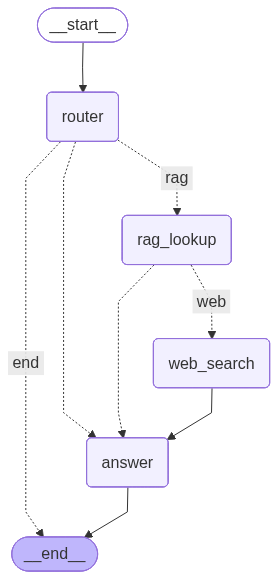

In [49]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

## Test

In [50]:
import json
from langchain_core.load import dumps

def chat(query: str, thread_id: str="test"):
    config = {"configurable": {"thread_id": thread_id}}
    res = agent.invoke({"messages": [HumanMessage(content=query)]}, config)

    last_answer = next((
        m
        for m in reversed(res["messages"])
        if isinstance(m, AIMessage)), 
        ""
    )
    last_prompt = next((
        m
        for m in reversed(res["messages"])
        if isinstance(m, HumanMessage)), 
        ""
    )
    print(f"👨: {last_prompt}\n🤖: {last_answer}")

    return res


res = chat("Hi, my name is John.")
res = chat("What is effective intensity?")
res = chat("Who first defined effective intensity?")
res = chat("What is my name?")


👨: content='Hi, my name is John.' additional_kwargs={} response_metadata={} id='8e8ebfd8-40ea-4541-bec0-3757e20b7154'
🤖: content='Hello John, nice to meet you!' additional_kwargs={} response_metadata={} id='948b5739-0663-4f70-bd89-f4f94c51af46' tool_calls=[] invalid_tool_calls=[]
DEBUG RAG called
DEBUG WEB called
👨: content='What is effective intensity?' additional_kwargs={} response_metadata={} id='695e3566-75ad-406c-a58d-55ad87c5671e'
🤖: content='John, effective intensity is a photometric parameter that measures the perceived brightness of flashing or pulsed light sources, taking into account how the human eye responds to them. It equates the visibility of these light sources to an equivalent continuous light source. This concept is crucial for safety, regulatory standards, and visual signaling.' additional_kwargs={} response_metadata={} id='07b718ae-d711-411b-a14e-e8ce22c78fa0' tool_calls=[] invalid_tool_calls=[]
DEBUG RAG called
DEBUG WEB called
👨: content='Who first defined effect

In [51]:
res

{'messages': [HumanMessage(content='Hi, my name is John.', additional_kwargs={}, response_metadata={}, id='8e8ebfd8-40ea-4541-bec0-3757e20b7154'),
  AIMessage(content='Hello John, nice to meet you!', additional_kwargs={}, response_metadata={}, id='948b5739-0663-4f70-bd89-f4f94c51af46', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What is effective intensity?', additional_kwargs={}, response_metadata={}, id='695e3566-75ad-406c-a58d-55ad87c5671e'),
  AIMessage(content='John, effective intensity is a photometric parameter that measures the perceived brightness of flashing or pulsed light sources, taking into account how the human eye responds to them. It equates the visibility of these light sources to an equivalent continuous light source. This concept is crucial for safety, regulatory standards, and visual signaling.', additional_kwargs={}, response_metadata={}, id='07b718ae-d711-411b-a14e-e8ce22c78fa0', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Wh

from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict
from random import randint
from langgraph.checkpoint.memory import MemorySaver

class TestState(TypedDict):
    id: str
    messages: Annotated[list[BaseMessage], add_messages]

def add_node(state: TestState) -> TestState:
    return {"messages": AIMessage(content=f"The counter {randint(1, 10)}.")}

def add_node_bis(state: TestState) -> TestState:
    i = randint(1, 10)
    return {**state, "id": f"{i}", "messages": state["messages"] + [AIMessage(content=f"The counter {i}.")]}

from langgraph.graph import StateGraph, START, END

g = StateGraph(TestState)
g.add_node("add_node", add_node_bis)

g.add_edge(START, "add_node")
g.add_edge("add_node", END)

a = g.compile(checkpointer=MemorySaver())

config = {"configurable": {"thread_id": "1"}}
res = a.invoke({"messages": [HumanMessage(content="first query.")]}, config)
print(res)
res = a.invoke({"messages": [HumanMessage(content="second query.")]}, config)
print(res)